0916 result summary -- wo/r/g/l/rg/rl/gl/rgl developmental mechanism comparison

three sections:

1. alpha=0.001 only, all rgl schedules included -- wo/r/g/l/rg/rl/gl/rgl, plus every rgl schedule variant
2. everything -- all alpha values, all schedules. same schedule = same color family
3. rgl only, alpha=0.001 only -- schedule comparison within rgl

4 chart types per section:
- CIFAR-10 clean accuracy
- CH index (representation separation)
- CIFAR-10-C accuracy + shape bias (behavioral robustness)
- linear probe transfer: noise/rotate/corrupt (representation-level robustness)

section 4: reCAPTCHA + SVRT same-different (using the 0.001-only tag set).

n=3 nets shown as black dots instead of error bars, mean value printed above each bar. font sizes are the FONT SIZE block below.

In [100]:
import os
import re
import json
import zipfile
import tarfile
import urllib.request
import random

import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms as T
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import sys
sys.path.append("..")
from src.data.degredation import get_transforms
from src.models.resnet import resnet18
from src.training.train import test as run_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

dataset_dir = "../dataset"
figure_dir = os.path.join("..", "figures", "evaluation_all")
os.makedirs(figure_dir, exist_ok=True)

CIFAR10_CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)
criterion = nn.CrossEntropyLoss()
SAVE_FIGURES = False

# ==== FONT SIZE options -- change these numbers to resize every chart below ====
TITLE_FONTSIZE = 13
AXIS_LABEL_FONTSIZE = 12
XTICK_FONTSIZE = 10
YTICK_FONTSIZE = 10
VALUE_LABEL_FONTSIZE = 10
LEGEND_FONTSIZE = 8

cuda


In [101]:
# ==== model registry -- includes the new schedules currently training (g5l10/g5l20/g20l5/g20l20) ====
save_dir = os.path.join("..", "results", "cifar10-0913")
num_net = 3

model_tags = [
    "wo", "r", "g", "l5_0.001", "l5_0.01", "rg",
    "rl_g10l5_0.001", "gl_g10l5_0.001",
    "rgl_g5l5_0.001", "rgl_g5l5_0.01",
    "rgl_g10l10_0.001", "rgl_g10l10_0.005", "rgl_g10l10_0.01",
    "rgl_g20l20_0.001",
    "rgl_g5l10_0.001",
    "rgl_g5l20_0.001",
    "rgl_g10l5_0.001", "rgl_g10l5_0.005", "rgl_g10l5_0.01",
    "rgl_g20l5_0.001",
]

def ckpt_path(tag, net_idx):
    return os.path.join(save_dir, f"best_model_{tag}_{net_idx}.pth")

def load_model(tag, net_idx):
    model = resnet18().to(device)
    model.load_state_dict(torch.load(ckpt_path(tag, net_idx), map_location=device))
    model.eval()
    return model

available_tags = [t for t in model_tags if all(os.path.exists(ckpt_path(t, i)) for i in range(num_net))]
missing_tags = [t for t in model_tags if t not in available_tags]
print(f"available ({len(available_tags)}): {available_tags}")
if missing_tags:
    print(f"missing  ({len(missing_tags)}): {missing_tags}")

available (20): ['wo', 'r', 'g', 'l5_0.001', 'l5_0.01', 'rg', 'rl_g10l5_0.001', 'gl_g10l5_0.001', 'rgl_g5l5_0.001', 'rgl_g5l5_0.01', 'rgl_g10l10_0.001', 'rgl_g10l10_0.005', 'rgl_g10l10_0.01', 'rgl_g20l20_0.001', 'rgl_g5l10_0.001', 'rgl_g5l20_0.001', 'rgl_g10l5_0.001', 'rgl_g10l5_0.005', 'rgl_g10l5_0.01', 'rgl_g20l5_0.001']


In [114]:
# ==== tag parsing / per-tag color helpers (which tags go in each graph is written directly in that graph's cell) ====
MECH_ORDER = ["r", "g", "l"]

def parse_tag(tag):
    # tag -> (mechanism set, schedule str or None, alpha float or None)
    if tag == "wo":
        return set(), None, None
    if tag in ("r", "g"):
        return {tag}, None, None
    if tag == "rg":
        return {"r", "g"}, None, None
    parts = tag.split("_")
    alpha = float(parts[-1])
    mech_token = parts[0]
    mech = {c for c in mech_token if c in MECH_ORDER}
    schedule = parts[1] if len(parts) == 3 else None
    return mech, schedule, alpha

def factor_count(tag):
    return len(parse_tag(tag)[0])

def display_label(tag):
    mech, schedule, alpha = parse_tag(tag)
    if tag == "wo":
        return "wo"
    base = "".join(m for m in MECH_ORDER if m in mech)
    return f"{base}({schedule})" if schedule else base

from matplotlib.patches import Patch

# ---- section 1 color: factor(mechanism 개수)별로 완전히 다른 색 ----
FACTOR_COLOR = {0: "gray", 1: "gold", 2: "tab:red", 3: "tab:blue"}

def factor_color(tag):
    return FACTOR_COLOR[factor_count(tag)]

FACTOR_LEGEND_HANDLES = [
    Patch(color="gray", label="factor 0 (wo)"),
    Patch(color="gold", label="factor 1"),
    Patch(color="tab:red", label="factor 2"),
    Patch(color="tab:blue", label="factor 3 (rgl)"),
]

# ---- section 2 color: 한 색 계열(파랑) 안에서 alpha가 작을수록 진하게 ----
ALPHA_CMAP = plt.get_cmap("Blues")
ALPHA_SHADE = {None: 0.3, 0.001: 0.95, 0.005: 0.6, 0.01: 0.35}

def alpha_color(tag):
    _, _, alpha = parse_tag(tag)
    return ALPHA_CMAP(ALPHA_SHADE.get(alpha, 0.5))

ALPHA_LEGEND_HANDLES = [
    Patch(color=ALPHA_CMAP(ALPHA_SHADE[0.001]), label="1/10"),
    Patch(color=ALPHA_CMAP(ALPHA_SHADE[0.005]), label="1/50"),
    Patch(color=ALPHA_CMAP(ALPHA_SHADE[0.01]), label="1/100"),
]

# ---- section 3 color: 전부 rgl이라 전부 파랑 계열, gradual% vs lr% 관계로 진하기만 다르게 ----
# g==l(균형): 진하게 / g<l(lr 창이 더 큼): 중간 / g>l(gradual 창이 더 큼): 연하게
def schedule_group(schedule):
    g, l = schedule[1:].split("l")
    g, l = int(g), int(l)
    if g == l:
        return "equal"
    return "lr_wider" if g < l else "grad_wider"

SCHEDULE_GROUP_CMAP = plt.get_cmap("Blues")
SCHEDULE_GROUP_SHADE = {"equal": 0.9, "lr_wider": 0.6, "grad_wider": 0.35}

def schedule_color(tag):
    _, schedule, _ = parse_tag(tag)
    group = schedule_group(schedule) if schedule else "equal"
    return SCHEDULE_GROUP_CMAP(SCHEDULE_GROUP_SHADE[group])

SCHEDULE_GROUP_LEGEND_HANDLES = [
    Patch(color=SCHEDULE_GROUP_CMAP(SCHEDULE_GROUP_SHADE["equal"]), label="g=l"),
    Patch(color=SCHEDULE_GROUP_CMAP(SCHEDULE_GROUP_SHADE["lr_wider"]), label="g<l"),
    Patch(color=SCHEDULE_GROUP_CMAP(SCHEDULE_GROUP_SHADE["grad_wider"]), label="g>l"),
]

In [98]:
# ==== shared constants only -- each chart below is written out on its own, no shared plotting function ====
DOT_OFFSETS = [-0.12, 0.0, 0.12]
DOT_OFFSETS_NARROW = [-0.05, 0.0, 0.05]

data / feature-extraction setup (metric computation cells reuse these)

In [22]:
# cifar10
class AttrlessDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        return image, label, -1


cifar_transform = get_transforms("cifar10", blur=0, color=1, test=True)
cifar_train = torchvision.datasets.CIFAR10(root=dataset_dir, train=True, download=True, transform=cifar_transform)
cifar_test = torchvision.datasets.CIFAR10(root=dataset_dir, train=False, download=True, transform=cifar_transform)
cifar_test_raw = torchvision.datasets.CIFAR10(root=dataset_dir, train=False, download=True)  # no transform, raw PIL

cifar_test_loader = DataLoader(AttrlessDataset(cifar_test), batch_size=256, shuffle=False, num_workers=0)
print(f"train={len(cifar_train)}, test={len(cifar_test)}")


@torch.no_grad()
def extract_features(model, dataset, indices=None, batch_size=256):
    # resnet18 avg_pool output (512-d) as representation
    ds = Subset(dataset, indices) if indices is not None else dataset
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    feats_out, labels_out = [], []

    def hook_fn(module, inp, out):
        feats_out.append(torch.flatten(out, 1).cpu().numpy())

    handle = model.avg_pool.register_forward_hook(hook_fn)
    for inputs, labels in loader:
        model(inputs.to(device))
        labels_out.append(labels.numpy())
    handle.remove()
    return np.concatenate(feats_out), np.concatenate(labels_out)


@torch.no_grad()
def extract_features_batch(model, batch):
    feats_out = []

    def hook_fn(module, inp, out):
        feats_out.append(torch.flatten(out, 1).cpu().numpy())

    handle = model.avg_pool.register_forward_hook(hook_fn)
    model(batch)
    handle.remove()
    return np.concatenate(feats_out)


pca_idx = np.random.RandomState(1).choice(len(cifar_test), 2000, replace=False)  # CH index feature subsample
probe_train_idx = np.random.RandomState(0).choice(len(cifar_train), 5000, replace=False)  # linear probe train subsample

train=50000, test=10000


In [23]:
# cifar-10-c
cifar10c_root = os.path.join(dataset_dir, "CIFAR-10-C")
cifar10c_url = "https://zenodo.org/records/2535967/files/CIFAR-10-C.tar?download=1"
labels_path = os.path.join(cifar10c_root, "labels.npy")
tar_path = os.path.join(dataset_dir, "CIFAR-10-C.tar")

if not os.path.exists(labels_path):
    need_download = True
    if os.path.exists(tar_path):
        try:
            with tarfile.open(tar_path) as tar:
                tar.getmembers()
            need_download = False
        except (tarfile.TarError, EOFError):
            os.remove(tar_path)
    if need_download:
        urllib.request.urlretrieve(cifar10c_url, tar_path)
    print("Extracting CIFAR-10-C...")
    with tarfile.open(tar_path) as tar:
        tar.extractall(dataset_dir, filter="data")
    if os.path.exists(tar_path):
        os.remove(tar_path)

CORRUPTIONS = [
    "brightness", "contrast", "defocus_blur", "elastic_transform", "fog", "frost",
    "gaussian_blur", "gaussian_noise", "glass_blur", "impulse_noise", "jpeg_compression",
    "motion_blur", "pixelate", "saturate", "shot_noise", "snow", "spatter",
    "speckle_noise", "zoom_blur",
]
CORRUPTION_SUBSAMPLE = 2000
SEVERITIES = [1, 2, 3, 4, 5]
PER_SEVERITY_SUBSAMPLE = CORRUPTION_SUBSAMPLE // len(SEVERITIES)


class CIFAR10CDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        return self.transform(img), int(self.labels[idx])


def evaluate_corruption_robustness_detailed(model, batch_size=256, per_severity_subsample=PER_SEVERITY_SUBSAMPLE, seed=0):
    labels_full = np.load(labels_path)
    rng = np.random.RandomState(seed)
    severity_idx = {
        sev: rng.choice(np.arange((sev - 1) * 10000, sev * 10000), min(per_severity_subsample, 10000), replace=False)
        for sev in SEVERITIES
    }
    model.eval()
    results = {}
    for corruption in CORRUPTIONS:
        path = os.path.join(cifar10c_root, f"{corruption}.npy")
        if not os.path.exists(path):
            continue
        arr = np.load(path, mmap_mode="r")
        results[corruption] = {}
        for sev, idx in severity_idx.items():
            images = arr[idx]
            lbls = labels_full[idx]
            loader = DataLoader(CIFAR10CDataset(images, lbls, cifar_transform), batch_size=batch_size, shuffle=False, num_workers=0)
            correct, total = 0, 0
            with torch.no_grad():
                for x, y in loader:
                    x, y = x.to(device), y.to(device)
                    correct += (model(x).argmax(1) == y).sum().item()
                    total += y.size(0)
            results[corruption][sev] = correct / total
    return results


def corruption_per_net_acc(detail_list):
    return [np.mean([acc for sevs in d.values() for acc in sevs.values()]) for d in detail_list]

In [24]:
# linear probe transfer (noise, rotate, corrupt)
CIFAR_MEAN = CIFAR10_MEAN
CIFAR_STD = CIFAR10_STD
_normalize = T.Normalize(CIFAR_MEAN, CIFAR_STD)

motion_blur_sev5 = np.load(os.path.join(cifar10c_root, "motion_blur.npy"))[40000:50000]  # severity 5, aligned to cifar_test_raw

perturbations = ["noise", "rotate", "corrupt"]
robust_idx = np.random.RandomState(3).choice(len(cifar_test_raw), 1000, replace=False)
robust_labels = np.array(cifar_test_raw.targets)[robust_idx]


def build_batch(indices, perturb):
    imgs = []
    for idx in indices:
        if perturb == "corrupt":
            img = Image.fromarray(motion_blur_sev5[idx])
        else:
            img, _ = cifar_test_raw[idx]
        x = T.functional.to_tensor(img)
        if perturb == "noise":
            x = torch.clamp(x + torch.randn_like(x) * 0.25, 0, 1)
        elif perturb == "rotate":
            x = T.functional.rotate(x, 30)
        imgs.append(_normalize(x))
    return torch.stack(imgs).to(device)


clean_batch = build_batch(robust_idx, "clean")
perturbed_batches = {p: build_batch(robust_idx, p) for p in perturbations}

In [25]:
# reCAPTCHA
recaptcha_root = os.path.join(dataset_dir, "recaptcha-dataset", "Training")
car_dir = os.path.join(recaptcha_root, "Car")
noncar_dirs = [d for d in os.listdir(recaptcha_root) if d not in ("Car", "Other") and os.path.isdir(os.path.join(recaptcha_root, d))]
car_files = [os.path.join(car_dir, f) for f in os.listdir(car_dir)]
noncar_files = []
for d in noncar_dirs:
    p = os.path.join(recaptcha_root, d)
    noncar_files += [os.path.join(p, f) for f in os.listdir(p)]
print(f"car images: {len(car_files)}, non-car images: {len(noncar_files)}")

recaptcha_transform = T.Compose([T.Resize((32, 32)), T.ToTensor(), T.Normalize(CIFAR10_MEAN, CIFAR10_STD)])
AUTOMOBILE_IDX = CIFAR10_CLASSES.index("automobile")


def load_recaptcha_image(path):
    return recaptcha_transform(Image.open(path).convert("RGB"))


def recaptcha_grid_eval(model, grid_size=4, num_trials=100, seed=0):
    rng = random.Random(seed)
    cells_n = grid_size * grid_size
    model.eval()
    exact_matches, cell_correct = 0, 0
    for _ in range(num_trials):
        n_car = rng.randint(1, cells_n - 1)
        chosen_car = rng.sample(car_files, n_car)
        chosen_noncar = rng.sample(noncar_files, cells_n - n_car)
        paths = chosen_car + chosen_noncar
        true_hits = [True] * n_car + [False] * (cells_n - n_car)
        order = list(range(cells_n))
        rng.shuffle(order)
        paths = [paths[i] for i in order]
        true_hits = [true_hits[i] for i in order]
        images = torch.stack([load_recaptcha_image(p) for p in paths]).to(device)
        with torch.no_grad():
            preds = model(images).argmax(1).cpu().tolist()
        pred_hits = [p == AUTOMOBILE_IDX for p in preds]
        if pred_hits == true_hits:
            exact_matches += 1
        cell_correct += sum(p == t for p, t in zip(pred_hits, true_hits))
    return exact_matches / num_trials, cell_correct / (num_trials * cells_n)

car images: 3504, non-car images: 6116


In [26]:
# Geirhos texture-shape cue-conflict - shape bias 
geirhos_root = os.path.join(dataset_dir, "geirhos-cue-conflict")
geirhos_stimuli_dir = os.path.join(geirhos_root, "style-transfer-preprocessed-512")
geirhos_zip_url = "https://github.com/rgeirhos/texture-vs-shape/archive/refs/heads/master.zip"
geirhos_zip_path = os.path.join(dataset_dir, "texture-vs-shape.zip")
ZIP_INNER_PREFIX = "texture-vs-shape-master/stimuli/style-transfer-preprocessed-512/"

if not os.path.exists(geirhos_stimuli_dir):
    os.makedirs(geirhos_root, exist_ok=True)
    urllib.request.urlretrieve(geirhos_zip_url, geirhos_zip_path)
    with zipfile.ZipFile(geirhos_zip_path) as zf:
        members = [m for m in zf.namelist() if m.startswith(ZIP_INNER_PREFIX) and not m.endswith("/")]
        for m in members:
            rel = m[len(ZIP_INNER_PREFIX):]
            dest = os.path.join(geirhos_stimuli_dir, rel)
            os.makedirs(os.path.dirname(dest), exist_ok=True)
            with zf.open(m) as src, open(dest, "wb") as out:
                out.write(src.read())
    os.remove(geirhos_zip_path)

SIN_TO_CIFAR = {"airplane": "airplane", "car": "automobile", "bird": "bird", "cat": "cat", "dog": "dog", "truck": "truck"}
OVERLAP_SIN_CLASSES = set(SIN_TO_CIFAR.keys())
OVERLAP_CIFAR_IDX = sorted(CIFAR10_CLASSES.index(c) for c in SIN_TO_CIFAR.values())
class_dirs = sorted(d for d in os.listdir(geirhos_stimuli_dir) if os.path.isdir(os.path.join(geirhos_stimuli_dir, d)))


def parse_shape_texture(filename):
    stem = os.path.splitext(filename)[0]
    shape_part, texture_part = stem.split("-")
    shape_cls = re.sub(r"\d+$", "", shape_part).lower()
    texture_cls = re.sub(r"\d+$", "", texture_part).lower()
    return shape_cls, texture_cls


geirhos_pairs = []
for shape_dir in class_dirs:
    dir_path = os.path.join(geirhos_stimuli_dir, shape_dir)
    for fname in os.listdir(dir_path):
        shape_cls, texture_cls = parse_shape_texture(fname)
        if shape_cls in OVERLAP_SIN_CLASSES and texture_cls in OVERLAP_SIN_CLASSES and shape_cls != texture_cls:
            geirhos_pairs.append((
                os.path.join(dir_path, fname),
                CIFAR10_CLASSES.index(SIN_TO_CIFAR[shape_cls]),
                CIFAR10_CLASSES.index(SIN_TO_CIFAR[texture_cls]),
            ))
print(f"cue-conflict images overlapping with 6 CIFAR classes: {len(geirhos_pairs)}")

geirhos_transform = T.Compose([T.Resize((32, 32)), T.ToTensor(), T.Normalize(CIFAR10_MEAN, CIFAR10_STD)])


@torch.no_grad()
def geirhos_shape_bias(model, pairs, batch_size=64):
    model.eval()
    shape_hits, texture_hits = 0, 0
    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i + batch_size]
        images = torch.stack([geirhos_transform(Image.open(p).convert("RGB")) for p, _, _ in batch]).to(device)
        logits = model(images)
        restricted = logits[:, OVERLAP_CIFAR_IDX]
        pred_idx = torch.tensor(OVERLAP_CIFAR_IDX, device=device)[restricted.argmax(1)]
        preds = pred_idx.cpu().tolist()
        for pred, (_, shape_idx, texture_idx) in zip(preds, batch):
            if pred == shape_idx:
                shape_hits += 1
            elif pred == texture_idx:
                texture_hits += 1
    denom = shape_hits + texture_hits
    return shape_hits / denom if denom > 0 else float("nan")

cue-conflict images overlapping with 6 CIFAR classes: 150


In [27]:
# SVRT
def random_blob_polygon(rng, num_vertices=None, base_radius=28, jitter=0.5):
    num_vertices = num_vertices or rng.randint(8, 16)
    angles = np.sort(rng.uniform(0, 2 * np.pi, num_vertices))
    radii = base_radius * (1 + rng.uniform(-jitter, jitter, num_vertices))
    return np.stack([radii * np.cos(angles), radii * np.sin(angles)], axis=1)


def sample_two_centers(rng, image_size, safe_radius, min_gap):
    lo, hi = safe_radius, image_size - safe_radius
    for _ in range(500):
        c1 = rng.uniform(lo, hi, size=2)
        angle = rng.uniform(0, 2 * np.pi)
        dist = rng.uniform(min_gap, min_gap * 1.6)
        c2 = c1 + dist * np.array([np.cos(angle), np.sin(angle)])
        if lo <= c2[0] <= hi and lo <= c2[1] <= hi:
            return c1, c2
    return c1, c2


def generate_svrt_example(same, rng, image_size=180, base_radius=28, jitter=0.35):
    safe_radius = base_radius * 1.4
    min_gap = base_radius * 2.8
    base_pts = random_blob_polygon(rng, base_radius=base_radius, jitter=jitter)
    center_a, center_b = sample_two_centers(rng, image_size, safe_radius, min_gap)
    pts_a = base_pts + np.array(center_a)
    other_pts = base_pts if same else random_blob_polygon(rng, base_radius=base_radius, jitter=jitter)
    pts_b = other_pts + np.array(center_b)
    img = Image.new("L", (image_size, image_size), color=255)
    draw = ImageDraw.Draw(img)
    draw.polygon([tuple(pt) for pt in pts_a], fill=0)
    draw.polygon([tuple(pt) for pt in pts_b], fill=0)
    return img


svrt_transform = T.Compose([T.Resize((32, 32)), T.Grayscale(num_output_channels=3), T.ToTensor(), T.Normalize(CIFAR10_MEAN, CIFAR10_STD)])
N_SVRT_TRAIN, N_SVRT_TEST = 2000, 500


def build_svrt_split(n, rng):
    images, labels = [], []
    for _ in range(n):
        same = rng.random() < 0.5
        images.append(svrt_transform(generate_svrt_example(same, rng)))
        labels.append(int(same))
    return torch.stack(images), np.array(labels)


svrt_rng = np.random.RandomState(42)
svrt_train_x, svrt_train_y = build_svrt_split(N_SVRT_TRAIN, svrt_rng)
svrt_test_x, svrt_test_y = build_svrt_split(N_SVRT_TEST, svrt_rng)
print(f"SVRT train={len(svrt_train_x)}, test={len(svrt_test_x)}")


@torch.no_grad()
def extract_features_tensor(model, images, batch_size=256):
    feats_out = []

    def hook_fn(module, inp, out):
        feats_out.append(torch.flatten(out, 1).cpu().numpy())

    handle = model.avg_pool.register_forward_hook(hook_fn)
    for i in range(0, len(images), batch_size):
        model(images[i:i + batch_size].to(device))
    handle.remove()
    return np.concatenate(feats_out)

SVRT train=2000, test=500


metric computation -- run once for every available tag, all sections below reuse these dicts

In [28]:
# ==== 1) CIFAR-10 clean accuracy ====
clean_acc_results = {}
for tag in available_tags:
    accs = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        _, acc = run_test(model, cifar_test_loader, criterion, device)
        accs.append(acc)
    clean_acc_results[tag] = accs
    print(f"{tag:20s}: clean acc {np.mean(accs)*100:.2f}")

wo                  : clean acc 90.36
r                   : clean acc 90.06
g                   : clean acc 90.43
l5_0.001            : clean acc 91.50
l5_0.01             : clean acc 85.80
rg                  : clean acc 90.15
rl_g10l5_0.001      : clean acc 89.91
gl_g10l5_0.001      : clean acc 89.92
rgl_g5l5_0.001      : clean acc 88.59
rgl_g5l5_0.01       : clean acc 81.45
rgl_g10l10_0.001    : clean acc 89.06
rgl_g10l10_0.005    : clean acc 85.92
rgl_g10l10_0.01     : clean acc 84.27
rgl_g20l20_0.001    : clean acc 87.31
rgl_g5l10_0.001     : clean acc 89.83
rgl_g5l20_0.001     : clean acc 91.39
rgl_g10l5_0.001     : clean acc 88.56
rgl_g10l5_0.005     : clean acc 85.08
rgl_g10l5_0.01      : clean acc 80.78
rgl_g20l5_0.001     : clean acc 87.81


In [29]:
# ==== 2) CH index (representation separation) ====
from sklearn.metrics import calinski_harabasz_score

ch_results = {}
for tag in available_tags:
    scores = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        feats, labels = extract_features(model, cifar_test, pca_idx)
        scores.append(calinski_harabasz_score(feats, labels))
    ch_results[tag] = scores
    print(f"{tag:20s}: CH index {np.mean(scores):.1f}")

wo                  : CH index 234.8
r                   : CH index 274.3
g                   : CH index 201.5
l5_0.001            : CH index 273.3
l5_0.01             : CH index 130.2
rg                  : CH index 276.1
rl_g10l5_0.001      : CH index 266.6
gl_g10l5_0.001      : CH index 232.8
rgl_g5l5_0.001      : CH index 226.8
rgl_g5l5_0.01       : CH index 183.3
rgl_g10l10_0.001    : CH index 211.6
rgl_g10l10_0.005    : CH index 171.8
rgl_g10l10_0.01     : CH index 165.0
rgl_g20l20_0.001    : CH index 161.0
rgl_g5l10_0.001     : CH index 224.8
rgl_g5l20_0.001     : CH index 231.2
rgl_g10l5_0.001     : CH index 234.9
rgl_g10l5_0.005     : CH index 171.3
rgl_g10l5_0.01      : CH index 159.3
rgl_g20l5_0.001     : CH index 225.2


In [30]:
# ==== 3a) CIFAR-10-C accuracy ====
corruption_detailed = {}
for tag in available_tags:
    per_net_detail = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        per_net_detail.append(evaluate_corruption_robustness_detailed(model))
    corruption_detailed[tag] = per_net_detail
    print(f"{tag:20s}: CIFAR-10-C acc {np.mean(corruption_per_net_acc(per_net_detail))*100:.2f}")

wo                  : CIFAR-10-C acc 72.89
r                   : CIFAR-10-C acc 70.98
g                   : CIFAR-10-C acc 74.77
l5_0.001            : CIFAR-10-C acc 71.39
l5_0.01             : CIFAR-10-C acc 68.27
rg                  : CIFAR-10-C acc 73.58
rl_g10l5_0.001      : CIFAR-10-C acc 67.25
gl_g10l5_0.001      : CIFAR-10-C acc 74.78
rgl_g5l5_0.001      : CIFAR-10-C acc 72.47
rgl_g5l5_0.01       : CIFAR-10-C acc 70.57
rgl_g10l10_0.001    : CIFAR-10-C acc 74.68
rgl_g10l10_0.005    : CIFAR-10-C acc 75.34
rgl_g10l10_0.01     : CIFAR-10-C acc 74.25
rgl_g20l20_0.001    : CIFAR-10-C acc 77.12
rgl_g5l10_0.001     : CIFAR-10-C acc 71.23
rgl_g5l20_0.001     : CIFAR-10-C acc 72.24
rgl_g10l5_0.001     : CIFAR-10-C acc 72.62
rgl_g10l5_0.005     : CIFAR-10-C acc 72.37
rgl_g10l5_0.01      : CIFAR-10-C acc 70.54
rgl_g20l5_0.001     : CIFAR-10-C acc 74.12


In [31]:
# ==== 3b) shape bias (Geirhos cue-conflict) ====
geirhos_results = {}
for tag in available_tags:
    per_net = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        per_net.append(geirhos_shape_bias(model, geirhos_pairs))
    geirhos_results[tag] = per_net
    print(f"{tag:20s}: shape bias {np.nanmean(per_net):.3f}")

wo                  : shape bias 0.789
r                   : shape bias 0.705
g                   : shape bias 0.776
l5_0.001            : shape bias 0.781
l5_0.01             : shape bias 0.734
rg                  : shape bias 0.779
rl_g10l5_0.001      : shape bias 0.737
gl_g10l5_0.001      : shape bias 0.829
rgl_g5l5_0.001      : shape bias 0.833
rgl_g5l5_0.01       : shape bias 0.829
rgl_g10l10_0.001    : shape bias 0.858
rgl_g10l10_0.005    : shape bias 0.894
rgl_g10l10_0.01     : shape bias 0.886
rgl_g20l20_0.001    : shape bias 0.888
rgl_g5l10_0.001     : shape bias 0.809
rgl_g5l20_0.001     : shape bias 0.790
rgl_g10l5_0.001     : shape bias 0.829
rgl_g10l5_0.005     : shape bias 0.852
rgl_g10l5_0.01      : shape bias 0.836
rgl_g20l5_0.001     : shape bias 0.863


In [32]:
# ==== 3c) linear-probe transfer under noise/rotate/corrupt (representation-level robustness) ====
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

probe_transfer_results = {}
for tag in available_tags:
    clean_accs = []
    perturb_accs = {p: [] for p in perturbations}
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        train_feats, train_labels = extract_features(model, cifar_train, probe_train_idx)
        scaler = StandardScaler().fit(train_feats)
        clf = LogisticRegression(max_iter=2000, C=1.0)
        clf.fit(scaler.transform(train_feats), train_labels)

        clean_feats = extract_features_batch(model, clean_batch)
        clean_accs.append(clf.score(scaler.transform(clean_feats), robust_labels))
        for p in perturbations:
            pert_feats = extract_features_batch(model, perturbed_batches[p])
            perturb_accs[p].append(clf.score(scaler.transform(pert_feats), robust_labels))
    probe_transfer_results[tag] = dict(clean=clean_accs, **perturb_accs)
    print(f"{tag:20s}: transfer clean={np.mean(clean_accs)*100:.1f} " + " ".join(f"{p}={np.mean(perturb_accs[p])*100:.1f}" for p in perturbations))

wo                  : transfer clean=90.1 noise=13.1 rotate=44.2 corrupt=61.3
r                   : transfer clean=90.0 noise=12.8 rotate=39.8 corrupt=59.6
g                   : transfer clean=89.9 noise=12.7 rotate=46.8 corrupt=61.3
l5_0.001            : transfer clean=91.7 noise=13.4 rotate=36.8 corrupt=58.8
l5_0.01             : transfer clean=83.7 noise=15.6 rotate=36.0 corrupt=50.0
rg                  : transfer clean=89.8 noise=13.1 rotate=43.4 corrupt=59.4
rl_g10l5_0.001      : transfer clean=89.8 noise=10.4 rotate=31.8 corrupt=55.9
gl_g10l5_0.001      : transfer clean=88.0 noise=22.9 rotate=43.2 corrupt=57.6
rgl_g5l5_0.001      : transfer clean=88.4 noise=20.7 rotate=42.8 corrupt=54.2
rgl_g5l5_0.01       : transfer clean=73.9 noise=30.5 rotate=33.0 corrupt=48.9
rgl_g10l10_0.001    : transfer clean=87.9 noise=25.2 rotate=41.2 corrupt=56.2
rgl_g10l10_0.005    : transfer clean=82.1 noise=34.4 rotate=37.9 corrupt=57.0
rgl_g10l10_0.01     : transfer clean=78.2 noise=35.3 rotate=33.6

In [33]:
# ==== 4a) reCAPTCHA grid task ====
recaptcha_results = {}
for tag in available_tags:
    per_net = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        per_net.append(recaptcha_grid_eval(model, grid_size=4, num_trials=100, seed=net_idx))
    recaptcha_results[tag] = per_net
    print(f"{tag:20s}: recaptcha cell acc {np.mean([x[1] for x in per_net])*100:.2f}")

wo                  : recaptcha cell acc 53.71
r                   : recaptcha cell acc 53.54
g                   : recaptcha cell acc 53.25
l5_0.001            : recaptcha cell acc 54.94
l5_0.01             : recaptcha cell acc 53.60
rg                  : recaptcha cell acc 53.25
rl_g10l5_0.001      : recaptcha cell acc 54.23
gl_g10l5_0.001      : recaptcha cell acc 54.04
rgl_g5l5_0.001      : recaptcha cell acc 53.06
rgl_g5l5_0.01       : recaptcha cell acc 52.73
rgl_g10l10_0.001    : recaptcha cell acc 52.71
rgl_g10l10_0.005    : recaptcha cell acc 52.69
rgl_g10l10_0.01     : recaptcha cell acc 52.54
rgl_g20l20_0.001    : recaptcha cell acc 52.79
rgl_g5l10_0.001     : recaptcha cell acc 53.40
rgl_g5l20_0.001     : recaptcha cell acc 54.33
rgl_g10l5_0.001     : recaptcha cell acc 53.19
rgl_g10l5_0.005     : recaptcha cell acc 52.73
rgl_g10l5_0.01      : recaptcha cell acc 52.42
rgl_g20l5_0.001     : recaptcha cell acc 52.85


In [34]:
# ==== 4b) SVRT same-different relational reasoning (linear probe) ====
svrt_results = {}
for tag in available_tags:
    accs = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        train_feats = extract_features_tensor(model, svrt_train_x)
        test_feats = extract_features_tensor(model, svrt_test_x)
        scaler = StandardScaler().fit(train_feats)
        clf = LogisticRegression(max_iter=2000, C=1.0)
        clf.fit(scaler.transform(train_feats), svrt_train_y)
        accs.append(clf.score(scaler.transform(test_feats), svrt_test_y))
    svrt_results[tag] = accs
    print(f"{tag:20s}: SVRT acc {np.mean(accs)*100:.2f}")

wo                  : SVRT acc 59.33
r                   : SVRT acc 62.33
g                   : SVRT acc 58.00
l5_0.001            : SVRT acc 59.80
l5_0.01             : SVRT acc 59.67
rg                  : SVRT acc 61.33
rl_g10l5_0.001      : SVRT acc 64.67
gl_g10l5_0.001      : SVRT acc 60.60
rgl_g5l5_0.001      : SVRT acc 63.93
rgl_g5l5_0.01       : SVRT acc 58.33
rgl_g10l10_0.001    : SVRT acc 63.07
rgl_g10l10_0.005    : SVRT acc 60.40
rgl_g10l10_0.01     : SVRT acc 58.40
rgl_g20l20_0.001    : SVRT acc 65.73
rgl_g5l10_0.001     : SVRT acc 63.27
rgl_g5l20_0.001     : SVRT acc 64.40
rgl_g10l5_0.001     : SVRT acc 61.40
rgl_g10l5_0.005     : SVRT acc 61.93
rgl_g10l5_0.01      : SVRT acc 58.87
rgl_g20l5_0.001     : SVRT acc 64.27


1. lr suppression 있는 것이 좋은가? 

In [ ]:
tags = [t for t in [
    "wo",
    "r",
    "g",
    "l5_0.001",
    "rg",
    "rl_g10l5_0.001",
    "gl_g10l5_0.001",
    "rgl_g5l5_0.001",
    "rgl_g10l10_0.001",
    "rgl_g20l20_0.001",
    "rgl_g5l10_0.001",
    "rgl_g5l20_0.001",
    "rgl_g10l5_0.001",
    "rgl_g20l5_0.001",
] if t in available_tags]
colors = [factor_color(t) for t in tags]

print(f"section 1 tags ({len(tags)}): {[display_label(t) for t in tags]}")

means = [np.mean(np.array(clean_acc_results[t]) * 100) for t in tags]
plt.figure(figsize=(max(6, len(tags) * 0.7), 4))
plt.bar(range(len(tags)), means, color=colors, zorder=2)
for xi, t in enumerate(tags):
    for off, v in zip(DOT_OFFSETS, np.array(clean_acc_results[t]) * 100):
        plt.scatter(xi + off, v, color="black", s=15, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + 2, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(range(len(tags)), [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20), fontsize=YTICK_FONTSIZE)
plt.ylabel("accuracy (%)", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("CIFAR-10 clean accuracy", fontsize=TITLE_FONTSIZE)
plt.legend(handles=FACTOR_LEGEND_HANDLES, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

In [ ]:
tags = [t for t in [
    "wo",
    "r",
    "g",
    "l5_0.001",
    "rg",
    "rl_g10l5_0.001",
    "gl_g10l5_0.001",
    "rgl_g5l5_0.001",
    "rgl_g10l10_0.001",
    "rgl_g20l20_0.001",
    "rgl_g5l10_0.001",
    "rgl_g5l20_0.001",
    "rgl_g10l5_0.001",
    "rgl_g20l5_0.001",
] if t in available_tags]
colors = [factor_color(t) for t in tags]

means = [np.mean(ch_results[t]) for t in tags]
pad = (max(means) - min(means) + 1e-9) * 0.05 + 1e-9
plt.figure(figsize=(max(6, len(tags) * 0.7), 4))
plt.bar(range(len(tags)), means, color=colors, zorder=2)
for xi, t in enumerate(tags):
    for off, v in zip(DOT_OFFSETS, ch_results[t]):
        plt.scatter(xi + off, v, color="black", s=15, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + pad, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(range(len(tags)), [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.yticks(fontsize=YTICK_FONTSIZE)
plt.ylabel("CH index", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("Representation separation: CH index", fontsize=TITLE_FONTSIZE)
plt.legend(handles=FACTOR_LEGEND_HANDLES, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

In [ ]:
tags = [t for t in [
    "wo",
    "r",
    "g",
    "l5_0.001",
    "rg",
    "rl_g10l5_0.001",
    "gl_g10l5_0.001",
    "rgl_g5l5_0.001",
    "rgl_g10l10_0.001",
    "rgl_g20l20_0.001",
    "rgl_g5l10_0.001",
    "rgl_g5l20_0.001",
    "rgl_g10l5_0.001",
    "rgl_g20l5_0.001",
] if t in available_tags]
colors = [factor_color(t) for t in tags]

means = [np.mean(np.array(geirhos_results[t]) * 100) for t in tags]
plt.figure(figsize=(max(6, len(tags) * 0.7), 4))
plt.bar(range(len(tags)), means, color=colors, zorder=2)
for xi, t in enumerate(tags):
    for off, v in zip(DOT_OFFSETS, np.array(geirhos_results[t]) * 100):
        plt.scatter(xi + off, v, color="black", s=15, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + 2, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(range(len(tags)), [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20), fontsize=YTICK_FONTSIZE)
plt.ylabel("shape bias (%)", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("Representation robustness (behavioral): shape bias", fontsize=TITLE_FONTSIZE)
plt.legend(handles=FACTOR_LEGEND_HANDLES, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

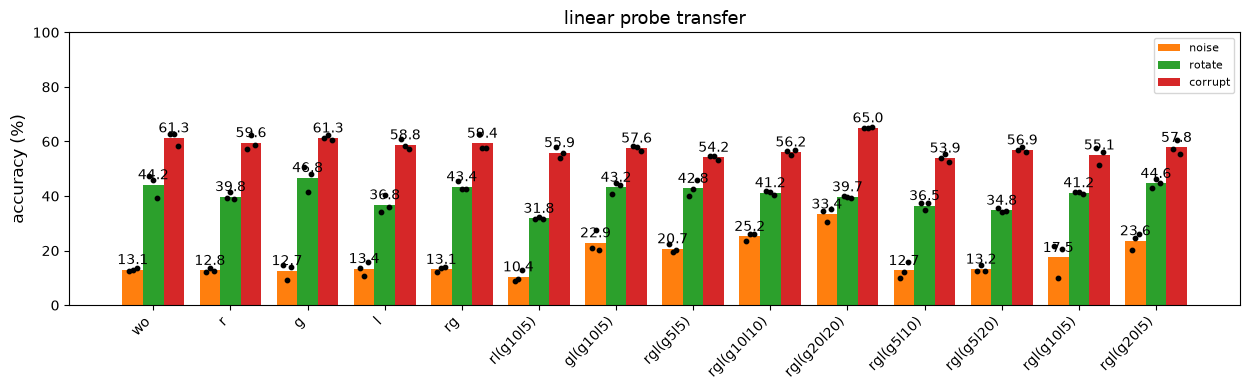

In [125]:
tags = [t for t in [
    "wo",
    "r",
    "g",
    "l5_0.001",
    "rg",
    "rl_g10l5_0.001",
    "gl_g10l5_0.001",
    "rgl_g5l5_0.001",
    "rgl_g10l10_0.001",
    "rgl_g20l20_0.001",
    "rgl_g5l10_0.001",
    "rgl_g5l20_0.001",
    "rgl_g10l5_0.001",
    "rgl_g20l5_0.001",
] if t in available_tags]
colors = [factor_color(t) for t in tags]

series = [
    ("noise", lambda t: np.array(probe_transfer_results[t]["noise"]) * 100, "tab:orange"),
    ("rotate", lambda t: np.array(probe_transfer_results[t]["rotate"]) * 100, "tab:green"),
    ("corrupt", lambda t: np.array(probe_transfer_results[t]["corrupt"]) * 100, "tab:red"),
]
width = 0.8 / len(series)
x = np.arange(len(tags))
plt.figure(figsize=(max(8, len(tags) * 0.9), 4))
for i, (name, get_vals, color) in enumerate(series):
    xpos = x + (i - (len(series) - 1) / 2) * width
    means = [np.mean(get_vals(t)) for t in tags]
    plt.bar(xpos, means, width, color=color, label=name, zorder=2)
    for xi, t in enumerate(tags):
        for off, v in zip(DOT_OFFSETS_NARROW, get_vals(t)):
            plt.scatter(xpos[xi] + off, v, color="black", s=10, zorder=3)
    for xi, m in enumerate(means):
        plt.text(xpos[xi], m + 2, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(x, [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20), fontsize=YTICK_FONTSIZE)
plt.ylabel("accuracy (%)", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("linear probe transfer", fontsize=TITLE_FONTSIZE)
plt.legend(fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

2. lr suppression 을 얼마나 하는 것이 좋은가 

section 2 tags (10): ['l5_0.001', 'l5_0.01', 'rgl_g5l5_0.001', 'rgl_g5l5_0.01', 'rgl_g10l10_0.001', 'rgl_g10l10_0.005', 'rgl_g10l10_0.01', 'rgl_g10l5_0.001', 'rgl_g10l5_0.005', 'rgl_g10l5_0.01']


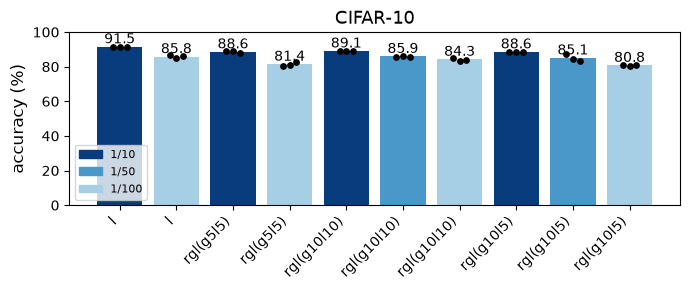

In [132]:
tags = [t for t in [
    "l5_0.001",
    "l5_0.01",
    "rgl_g5l5_0.001",
    "rgl_g5l5_0.01",
    "rgl_g10l10_0.001",
    "rgl_g10l10_0.005",
    "rgl_g10l10_0.01",
    "rgl_g10l5_0.001",
    "rgl_g10l5_0.005",
    "rgl_g10l5_0.01",
] if t in available_tags]
colors = [alpha_color(t) for t in tags]

print(f"section 2 tags ({len(tags)}): {tags}")

means = [np.mean(np.array(clean_acc_results[t]) * 100) for t in tags]
plt.figure(figsize=(max(6, len(tags) * 0.7), 3))
plt.bar(range(len(tags)), means, color=colors, zorder=2)
for xi, t in enumerate(tags):
    for off, v in zip(DOT_OFFSETS, np.array(clean_acc_results[t]) * 100):
        plt.scatter(xi + off, v, color="black", s=15, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + 2, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(range(len(tags)), [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20), fontsize=YTICK_FONTSIZE)
plt.ylabel("accuracy (%)", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("CIFAR-10", fontsize=TITLE_FONTSIZE)

plt.legend(handles=ALPHA_LEGEND_HANDLES, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

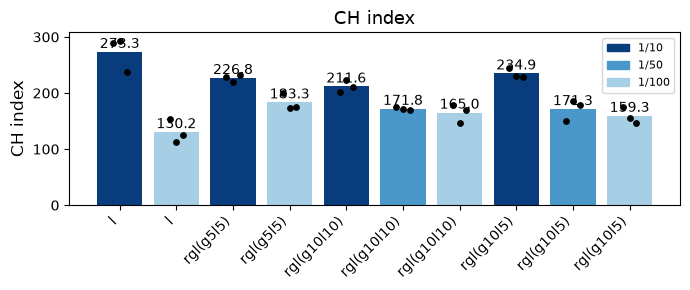

In [133]:
tags = [t for t in [
    "l5_0.001",
    "l5_0.01",
    "rgl_g5l5_0.001",
    "rgl_g5l5_0.01",
    "rgl_g10l10_0.001",
    "rgl_g10l10_0.005",
    "rgl_g10l10_0.01",
    "rgl_g10l5_0.001",
    "rgl_g10l5_0.005",
    "rgl_g10l5_0.01",
] if t in available_tags]
colors = [alpha_color(t) for t in tags]

means = [np.mean(ch_results[t]) for t in tags]
pad = (max(means) - min(means) + 1e-9) * 0.05 + 1e-9
plt.figure(figsize=(max(6, len(tags) * 0.7), 3))
plt.bar(range(len(tags)), means, color=colors, zorder=2)
for xi, t in enumerate(tags):
    for off, v in zip(DOT_OFFSETS, ch_results[t]):
        plt.scatter(xi + off, v, color="black", s=15, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + pad, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(range(len(tags)), [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.yticks(fontsize=YTICK_FONTSIZE)
plt.ylabel("CH index", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("CH index", fontsize=TITLE_FONTSIZE)
plt.legend(handles=ALPHA_LEGEND_HANDLES, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

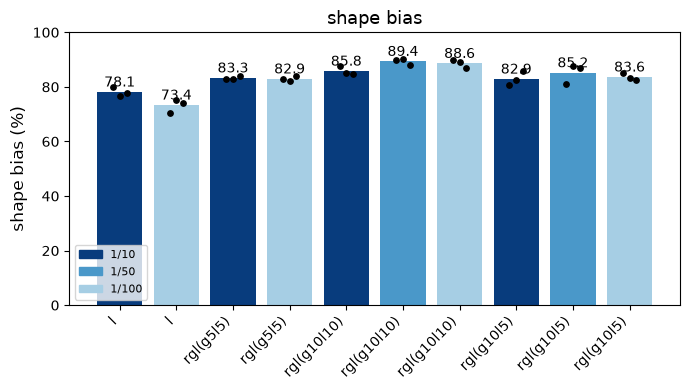

In [ ]:
tags = [t for t in [
    "l5_0.001",
    "l5_0.01",
    "rgl_g5l5_0.001",
    "rgl_g5l5_0.01",
    "rgl_g10l10_0.001",
    "rgl_g10l10_0.005",
    "rgl_g10l10_0.01",
    "rgl_g10l5_0.001",
    "rgl_g10l5_0.005",
    "rgl_g10l5_0.01",
] if t in available_tags]
colors = [alpha_color(t) for t in tags]

means = [np.mean(np.array(geirhos_results[t]) * 100) for t in tags]
plt.figure(figsize=(max(6, len(tags) * 0.7), 3))
plt.bar(range(len(tags)), means, color=colors, zorder=2)
for xi, t in enumerate(tags):
    for off, v in zip(DOT_OFFSETS, np.array(geirhos_results[t]) * 100):
        plt.scatter(xi + off, v, color="black", s=15, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + 2, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(range(len(tags)), [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20), fontsize=YTICK_FONTSIZE)
plt.ylabel("shape bias (%)", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("shape bias", fontsize=TITLE_FONTSIZE)
plt.legend(handles=ALPHA_LEGEND_HANDLES, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

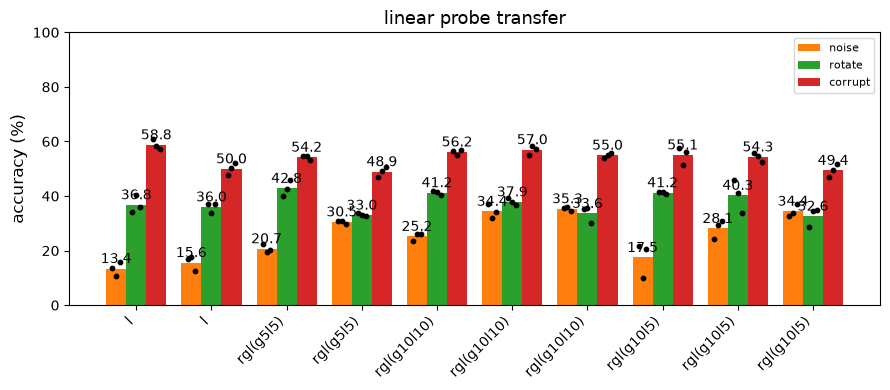

In [123]:
tags = [t for t in [
    "l5_0.001",
    "l5_0.01",
    "rgl_g5l5_0.001",
    "rgl_g5l5_0.01",
    "rgl_g10l10_0.001",
    "rgl_g10l10_0.005",
    "rgl_g10l10_0.01",
    "rgl_g10l5_0.001",
    "rgl_g10l5_0.005",
    "rgl_g10l5_0.01",
] if t in available_tags]
colors = [alpha_color(t) for t in tags]

series = [
    ("noise", lambda t: np.array(probe_transfer_results[t]["noise"]) * 100, "tab:orange"),
    ("rotate", lambda t: np.array(probe_transfer_results[t]["rotate"]) * 100, "tab:green"),
    ("corrupt", lambda t: np.array(probe_transfer_results[t]["corrupt"]) * 100, "tab:red"),
]
width = 0.8 / len(series)
x = np.arange(len(tags))
plt.figure(figsize=(max(8, len(tags) * 0.9), 4))
for i, (name, get_vals, color) in enumerate(series):
    xpos = x + (i - (len(series) - 1) / 2) * width
    means = [np.mean(get_vals(t)) for t in tags]
    plt.bar(xpos, means, width, color=color, label=name, zorder=2)
    for xi, t in enumerate(tags):
        for off, v in zip(DOT_OFFSETS_NARROW, get_vals(t)):
            plt.scatter(xpos[xi] + off, v, color="black", s=10, zorder=3)
    for xi, m in enumerate(means):
        plt.text(xpos[xi], m + 2, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(x, [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20), fontsize=YTICK_FONTSIZE)
plt.ylabel("accuracy (%)", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("linear probe transfer", fontsize=TITLE_FONTSIZE)
plt.legend(fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

## Section 3 -- rgl only, alpha=0.001 only: schedule comparison
color = one hue per schedule (same palette as section 2)

section 3 tags (7): ['rgl(g5l5)', 'rgl(g10l10)', 'rgl(g20l20)', 'rgl(g5l10)', 'rgl(g5l20)', 'rgl(g10l5)', 'rgl(g20l5)']


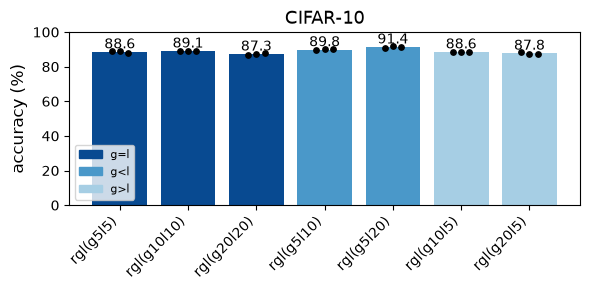

In [127]:
tags = [t for t in [
    "rgl_g5l5_0.001",
    "rgl_g10l10_0.001",
    "rgl_g20l20_0.001",
    "rgl_g5l10_0.001",
    "rgl_g5l20_0.001",
    "rgl_g10l5_0.001",
    "rgl_g20l5_0.001",
] if t in available_tags]
colors = [schedule_color(t) for t in tags]

print(f"section 3 tags ({len(tags)}): {[display_label(t) for t in tags]}")

means = [np.mean(np.array(clean_acc_results[t]) * 100) for t in tags]
plt.figure(figsize=(max(6, len(tags) * 0.7), 3))
plt.bar(range(len(tags)), means, color=colors, zorder=2)
for xi, t in enumerate(tags):
    for off, v in zip(DOT_OFFSETS, np.array(clean_acc_results[t]) * 100):
        plt.scatter(xi + off, v, color="black", s=15, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + 2, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(range(len(tags)), [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20), fontsize=YTICK_FONTSIZE)
plt.ylabel("accuracy (%)", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("CIFAR-10", fontsize=TITLE_FONTSIZE)
plt.legend(handles=SCHEDULE_GROUP_LEGEND_HANDLES, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

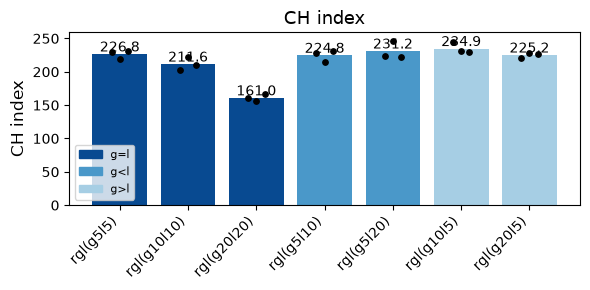

In [128]:
tags = [t for t in [
    "rgl_g5l5_0.001",
    "rgl_g10l10_0.001",
    "rgl_g20l20_0.001",
    "rgl_g5l10_0.001",
    "rgl_g5l20_0.001",
    "rgl_g10l5_0.001",
    "rgl_g20l5_0.001",
] if t in available_tags]
colors = [schedule_color(t) for t in tags]

means = [np.mean(ch_results[t]) for t in tags]
pad = (max(means) - min(means) + 1e-9) * 0.05 + 1e-9
plt.figure(figsize=(max(6, len(tags) * 0.7), 3))
plt.bar(range(len(tags)), means, color=colors, zorder=2)
for xi, t in enumerate(tags):
    for off, v in zip(DOT_OFFSETS, ch_results[t]):
        plt.scatter(xi + off, v, color="black", s=15, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + pad, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(range(len(tags)), [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.yticks(fontsize=YTICK_FONTSIZE)
plt.ylabel("CH index", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("CH index", fontsize=TITLE_FONTSIZE)
plt.legend(handles=SCHEDULE_GROUP_LEGEND_HANDLES, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

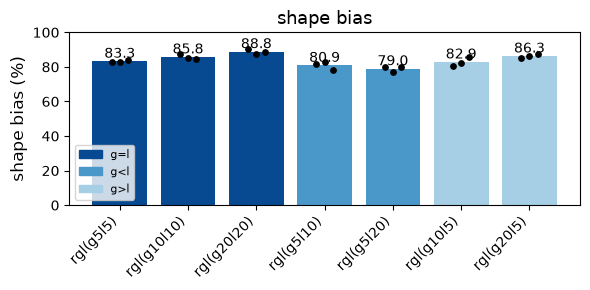

In [130]:
tags = [t for t in [
    "rgl_g5l5_0.001",
    "rgl_g10l10_0.001",
    "rgl_g20l20_0.001",
    "rgl_g5l10_0.001",
    "rgl_g5l20_0.001",
    "rgl_g10l5_0.001",
    "rgl_g20l5_0.001",
] if t in available_tags]
colors = [schedule_color(t) for t in tags]

means = [np.mean(np.array(geirhos_results[t]) * 100) for t in tags]
plt.figure(figsize=(max(6, len(tags) * 0.7), 3))
plt.bar(range(len(tags)), means, color=colors, zorder=2)
for xi, t in enumerate(tags):
    for off, v in zip(DOT_OFFSETS, np.array(geirhos_results[t]) * 100):
        plt.scatter(xi + off, v, color="black", s=15, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + 2, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(range(len(tags)), [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20), fontsize=YTICK_FONTSIZE)
plt.ylabel("shape bias (%)", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("shape bias", fontsize=TITLE_FONTSIZE)
plt.legend(handles=SCHEDULE_GROUP_LEGEND_HANDLES, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

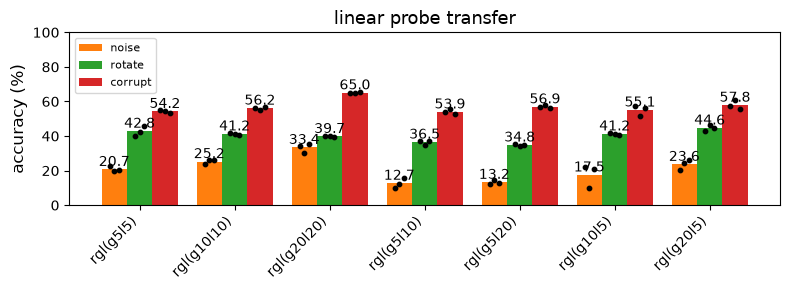

In [131]:
tags = [t for t in [
    "rgl_g5l5_0.001",
    "rgl_g10l10_0.001",
    "rgl_g20l20_0.001",
    "rgl_g5l10_0.001",
    "rgl_g5l20_0.001",
    "rgl_g10l5_0.001",
    "rgl_g20l5_0.001",
] if t in available_tags]
colors = [schedule_color(t) for t in tags]

series = [
    ("noise", lambda t: np.array(probe_transfer_results[t]["noise"]) * 100, "tab:orange"),
    ("rotate", lambda t: np.array(probe_transfer_results[t]["rotate"]) * 100, "tab:green"),
    ("corrupt", lambda t: np.array(probe_transfer_results[t]["corrupt"]) * 100, "tab:red"),
]
width = 0.8 / len(series)
x = np.arange(len(tags))
plt.figure(figsize=(max(8, len(tags) * 0.9), 3))
for i, (name, get_vals, color) in enumerate(series):
    xpos = x + (i - (len(series) - 1) / 2) * width
    means = [np.mean(get_vals(t)) for t in tags]
    plt.bar(xpos, means, width, color=color, label=name, zorder=2)
    for xi, t in enumerate(tags):
        for off, v in zip(DOT_OFFSETS_NARROW, get_vals(t)):
            plt.scatter(xpos[xi] + off, v, color="black", s=10, zorder=3)
    for xi, m in enumerate(means):
        plt.text(xpos[xi], m + 2, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(x, [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20), fontsize=YTICK_FONTSIZE)
plt.ylabel("accuracy (%)", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("linear probe transfer", fontsize=TITLE_FONTSIZE)
plt.legend(fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

## Section 4 -- reCAPTCHA + SVRT same-different (0.001-only tag set)

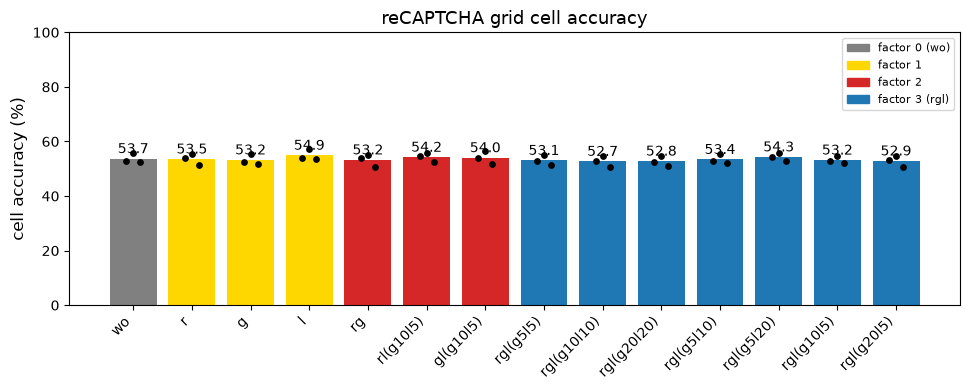

In [120]:
tags = [t for t in [
    "wo",
    "r",
    "g",
    "l5_0.001",
    "rg",
    "rl_g10l5_0.001",
    "gl_g10l5_0.001",
    "rgl_g5l5_0.001",
    "rgl_g10l10_0.001",
    "rgl_g20l20_0.001",
    "rgl_g5l10_0.001",
    "rgl_g5l20_0.001",
    "rgl_g10l5_0.001",
    "rgl_g20l5_0.001",
] if t in available_tags]
colors = [factor_color(t) for t in tags]

means = [np.mean([x[1] * 100 for x in recaptcha_results[t]]) for t in tags]
plt.figure(figsize=(max(6, len(tags) * 0.7), 4))
plt.bar(range(len(tags)), means, color=colors, zorder=2)
for xi, t in enumerate(tags):
    for off, v in zip(DOT_OFFSETS, [x[1] * 100 for x in recaptcha_results[t]]):
        plt.scatter(xi + off, v, color="black", s=15, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + 2, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(range(len(tags)), [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20), fontsize=YTICK_FONTSIZE)
plt.ylabel("cell accuracy (%)", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("reCAPTCHA grid cell accuracy", fontsize=TITLE_FONTSIZE)
plt.legend(handles=FACTOR_LEGEND_HANDLES, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

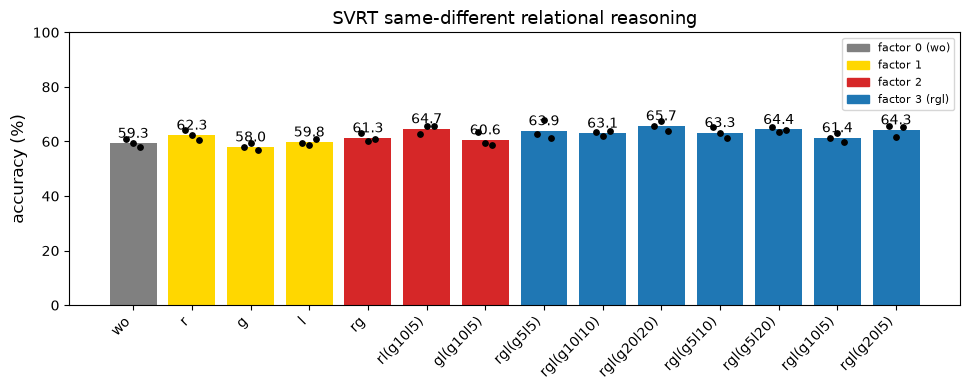

In [122]:
tags = [t for t in [
    "wo",
    "r",
    "g",
    "l5_0.001",
    "rg",
    "rl_g10l5_0.001",
    "gl_g10l5_0.001",
    "rgl_g5l5_0.001",
    "rgl_g10l10_0.001",
    "rgl_g20l20_0.001",
    "rgl_g5l10_0.001",
    "rgl_g5l20_0.001",
    "rgl_g10l5_0.001",
    "rgl_g20l5_0.001",
] if t in available_tags]
colors = [factor_color(t) for t in tags]

means = [np.mean(np.array(svrt_results[t]) * 100) for t in tags]
plt.figure(figsize=(max(6, len(tags) * 0.7), 4))
plt.bar(range(len(tags)), means, color=colors, zorder=2)
for xi, t in enumerate(tags):
    for off, v in zip(DOT_OFFSETS, np.array(svrt_results[t]) * 100):
        plt.scatter(xi + off, v, color="black", s=15, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + 2, f"{m:.1f}", ha="center", fontsize=VALUE_LABEL_FONTSIZE)
plt.xticks(range(len(tags)), [display_label(t) for t in tags], rotation=45, ha="right", fontsize=XTICK_FONTSIZE)
plt.ylim(0, 100)
plt.yticks(range(0, 101, 20), fontsize=YTICK_FONTSIZE)
plt.ylabel("accuracy (%)", fontsize=AXIS_LABEL_FONTSIZE)
plt.title("SVRT same-different relational reasoning", fontsize=TITLE_FONTSIZE)
plt.legend(handles=FACTOR_LEGEND_HANDLES, fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()